In [1]:
from Creador import generar_instancia_irp  
from Instancia import Instancia
from Proceso import Proceso
from Politica import PoliticaSimple, PoliticaSimpleClusterisada, RollOutSimple, RollOutCluster, MonteCarlo
from FuncionesAuxiliares import kmeans_clustering, visualizar_clusters, kmeans_clustering_sklearn
import numpy as np
import os
from Generador_de_instancias import n_instancias, generar_instancias, semillas
from Simulacion import Simulacion
from Resultados import Resultados
import matplotlib.pyplot as plt

In [ ]:
#generar_instancias(semillas=semillas)

Se generaron los archivos de instancia correctamente


In [3]:
# Parámetros de la simulación
#carpeta_instancias = "INSTANCIAS FREE"
#n_repeticiones = 1

# Ejecutar la simulación
#simulacion = Simulacion(carpeta_instancias, n_instancias, n_repeticiones)
#resultados = simulacion.ejecutar()

In [4]:
resultados = Resultados( nombre_archivo= 'resultadosPoliticasSimpleYCluster.xlsx')

resultados = resultados.leer_archivo()

In [5]:
resultados['Costo Traslado Simple'].mean()

np.float64(0.41586459029561046)

In [6]:
resultados['Costo Traslado Clusterizado'].mean()

np.float64(0.29877567857657605)

In [7]:
resultados['Costo Total Simple'].mean()

np.float64(1897.5383064862312)

In [8]:
resultados['Costo Total Clusterizado'].mean()

np.float64(2179.073354747131)

In [9]:
resultados['Costo total Rollout Simple'].mean()

np.float64(1284.783988673995)

In [10]:
resultados['Costo total RollOut Clusterizado'].mean()

np.float64(1139.2834645673354)

# EJECUCIÓN DE INSTANCIA DE EJEMPLO

In [3]:
# Generar instancia (ARCHIVO XML)
mensaje = generar_instancia_irp(
        ancho_zona = 2000, 
        largo_zona = 2000, 
        horizonte_tiempo = 480, 
        num_productos =2,
        num_clientes = 15, 
        num_vehiculos = 4, 
        semilla = 1, 
        carpeta_instancias= "Instancias 400",
        nombre_archivo= 'instancia1.xml'
    )

In [4]:
carpeta_instancias = "Instancias 400"
ruta_completa = os.path.join(carpeta_instancias, f'instancia1.xml')
# Lectura de la instancia y se guarda en un objeto instancia
instancia = Instancia(ruta_archivo=ruta_completa, umbral_inventario_clientes= 0.2, umbral_inventario_vehiculos= 0.1)
# Se genera el proceso mediante la instancia
proceso = Proceso(instancia)
politicaSimple = PoliticaSimple(instancia,proceso)
politicaClusterisada = PoliticaSimpleClusterisada(instancia,proceso)

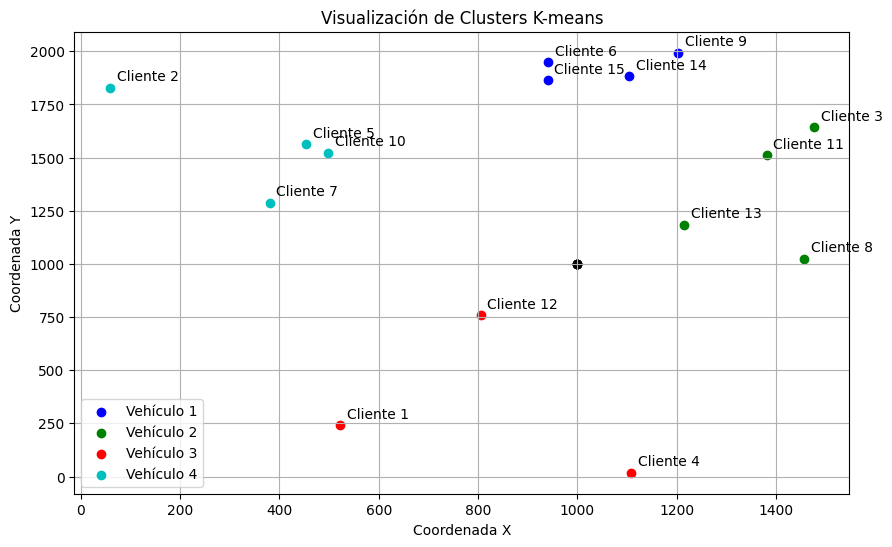

In [5]:
# Inicializamos el númmero de clusters
M = len(instancia.vehiculos.keys())
#Obtenemos las posiciones de los clientes
posiciones_clientes = { idc: {'x':cliente.posicion_x, 'y': cliente.posicion_y} for idc, cliente in instancia.clientes.items()}

# Ejecutar k-means (usando la función anterior)
clusters = kmeans_clustering_sklearn(M, posiciones_clientes)

# Visualizar resultados
visualizar_clusters(posiciones_clientes, clusters, {'x': instancia.depot_X, 'y': instancia.depot_Y})

In [6]:
print(f'los vehiculos son: \n {instancia.vehiculos}')
print(f'los clientes son:  \n {instancia.clientes}')
print(f'los productos son : \n {instancia.productos}')
print(f'las demandas medias son: {instancia.demandas_medias}')
print(instancia.depot_X)
print(instancia.depot_Y)

los vehiculos son: 
 {1: Vehiculo(id=1, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 261, 2: 337}), 2: Vehiculo(id=2, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 261, 2: 337}), 3: Vehiculo(id=3, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 261, 2: 337}), 4: Vehiculo(id=4, capacidad=600.0, velocidad_media=50.0, desv_est_velocidad=5.0, inventario={1: 261, 2: 337})}
los clientes son:  
 {1: Cliente(id=1, posicion_x=522.0, posicion_y=241.0, capacidad_almacenamiento=199.0, inventarios_iniciales={1: 10.0, 2: 10.0}, costos_inventario={1: 0.0, 2: 0.0}, costos_penalizacion={1: 50.0, 2: 87.0}, demanda_media={1: 2.0, 2: 2.0}, demanda_desv_est={1: 2.3, 2: 1.19}), 2: Cliente(id=2, posicion_x=58.0, posicion_y=1829.0, capacidad_almacenamiento=267.0, inventarios_iniciales={1: 10.0, 2: 10.0}, costos_inventario={1: 0.0, 2: 0.0}, costos_penalizacion={1: 48.0, 2: 1.0}, demanda_media={1: 1.0, 2: 2.0}, demand

# Política simple

In [7]:
costos = np.array([])
traslado = np.array([])
n=100
for _ in range(n):
    trayectoriaSimple, costo_traslado , _ = politicaSimple.run()  
    traslado  =  np.append(traslado,costo_traslado)
    #for estado_accion in trayectoriaSimple:
        #print(estado_accion['estado'])
        #print(estado_accion['accion'])
    costo =sum(estado_accion['recompensa'] for estado_accion in trayectoriaSimple)
    costos = np.append(costos,costo)
promedio_simple = np.mean(costos)
trasladdo_promedio = np.mean(traslado)
print(promedio_simple)
print(trasladdo_promedio)

for t in trayectoriaSimple:
    print(t['estado'])
    print(t['accion'])

811201.8897327431
0.11262252369232473

    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 10.0, 2: 10.0}, 2: {1: 10.0, 2: 10.0}, 3: {1: 10.0, 2: 10.0}, 4: {1: 10.0, 2: 10.0}, 5: {1: 10.0, 2: 10.0}, 6: {1: 10.0, 2: 10.0}, 7: {1: 10.0, 2: 10.0}, 8: {1: 10.0, 2: 10.0}, 9: {1: 10.0, 2: 10.0}, 10: {1: 10.0, 2: 10.0}, 11: {1: 10.0, 2: 10.0}, 12: {1: 10.0, 2: 10.0}, 13: {1: 10.0, 2: 10.0}, 14: {1: 10.0, 2: 10.0}, 15: {1: 10.0, 2: 10.0}}
        Inventarios de vehículos: 
        {1: {1: 261, 2: 337}, 2: {1: 261, 2: 337}, 3: {1: 261, 2: 337}, 4: {1: 261, 2: 337}}
        Planificación de entregas:
        {1: {}, 2: {}, 3: {}, 4: {}}
        Tiempo transcurrido: 0.00 unidades de tiempo
        Posiciones de vehículos:
        {1: {'x': 1000.0, 'y': 1000.0}, 2: {'x': 1000.0, 'y': 1000.0}, 3: {'x': 1000.0, 'y': 1000.0}, 4: {'x': 1000.0, 'y': 1000.0}}
        
{1: {1: {1: 261, 2: 299}}}

    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 1.0, 2: 8.0},

# Instancia Clusterizada

In [8]:
costos = np.array([])
traslado = np.array([])
n=100
for _ in range(n):
    trayectoriaSimple, costo_traslado , _ = politicaClusterisada.run()
    traslado  =  np.append(traslado,costo_traslado)
    #for estado_accion in trayectoriaSimple:
        #print(estado_accion['estado'])
        #print(estado_accion['accion'])
    costo =sum(estado_accion['recompensa'] for estado_accion in trayectoriaSimple)
    costos = np.append(costos,costo)
promedio_cluster = np.mean(costos)
promedio_traslado = np.mean(traslado)
print(promedio_cluster)
print(promedio_traslado)


548627.4317044562
0.1592627517014816


# Implementamos la Rollout Simple ahora

In [9]:
PoliticaRollout = RollOutSimple(instancia= instancia, proceso= proceso)
'''
trayectoria_rollout_simple,_,_ = PoliticaRollout.run()

#for i in trayectoria_rollout_simple:
 #   print(i['estado'])
  #  print(i['accion'])
sum(i['recompensa'] for i in trayectoria_rollout_simple)
'''
costos = np.array([])

# ejecutamos 10 veces la política rollout
for _ in range(3):
    trayectoria_rollout,_,_ = PoliticaRollout.run()
    costo_episodio =  sum(i['recompensa'] for i in trayectoria_rollout)
    costos = np.append(costos,costo_episodio)

promedio_costo_rollout_simple = np.mean(costos)
print(promedio_costo_rollout_simple)

806510.6985605705


# Ahora implementamos la RollOut clusterizada

In [10]:
PoliticaRolloutCluster = RollOutCluster( instancia= instancia, proceso= proceso)

costos = np.array([])
# ejecutamos 10 veces la política rollout cluster
for _ in range(3):
    trayectoria_rollout_cluster,_,_ = PoliticaRolloutCluster.run()
    costos = np.append(costos, sum( i['recompensa'] for i in trayectoria_rollout_cluster))
promedio_costo_rollout_cluster = np.mean(costos)
print(promedio_costo_rollout_cluster)
for t in trayectoria_rollout_cluster:
    print(t['estado'])
    print(t['accion'])

759479.9235561173

    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 10.0, 2: 10.0}, 2: {1: 10.0, 2: 10.0}, 3: {1: 10.0, 2: 10.0}, 4: {1: 10.0, 2: 10.0}, 5: {1: 10.0, 2: 10.0}, 6: {1: 10.0, 2: 10.0}, 7: {1: 10.0, 2: 10.0}, 8: {1: 10.0, 2: 10.0}, 9: {1: 10.0, 2: 10.0}, 10: {1: 10.0, 2: 10.0}, 11: {1: 10.0, 2: 10.0}, 12: {1: 10.0, 2: 10.0}, 13: {1: 10.0, 2: 10.0}, 14: {1: 10.0, 2: 10.0}, 15: {1: 10.0, 2: 10.0}}
        Inventarios de vehículos: 
        {1: {1: 261, 2: 337}, 2: {1: 261, 2: 337}, 3: {1: 261, 2: 337}, 4: {1: 261, 2: 337}}
        Planificación de entregas:
        {1: {}, 2: {}, 3: {}, 4: {}}
        Tiempo transcurrido: 0.00 unidades de tiempo
        Posiciones de vehículos:
        {1: {'x': 1000.0, 'y': 1000.0}, 2: {'x': 1000.0, 'y': 1000.0}, 3: {'x': 1000.0, 'y': 1000.0}, 4: {'x': 1000.0, 'y': 1000.0}}
        
{1: {8: {1: 199, 2: 337}}}

    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 3.0, 2: 5.0}, 2: {1: 4.0, 2: 2.0}

# implementamos la política MC OnPolicy

In [11]:
MC = MonteCarlo(instancia = instancia, proceso = proceso, episodios = 5000, epsilon=0.05, learning_rate=0.0005)

In [12]:
MC.entrenar_modelo()

In [17]:
trayectoria_MC, traslado = MC.ejecutar_politica_mejores_betas()
print(traslado)
sum( i['recompensa'] for i in trayectoria_MC)

85952.92600353506


np.float64(519884.92600353516)

In [18]:
for t in trayectoria_MC:
    print(t['estado'])
    print(t['accion'])


    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 10.0, 2: 10.0}, 2: {1: 10.0, 2: 10.0}, 3: {1: 10.0, 2: 10.0}, 4: {1: 10.0, 2: 10.0}, 5: {1: 10.0, 2: 10.0}, 6: {1: 10.0, 2: 10.0}, 7: {1: 10.0, 2: 10.0}, 8: {1: 10.0, 2: 10.0}, 9: {1: 10.0, 2: 10.0}, 10: {1: 10.0, 2: 10.0}, 11: {1: 10.0, 2: 10.0}, 12: {1: 10.0, 2: 10.0}, 13: {1: 10.0, 2: 10.0}, 14: {1: 10.0, 2: 10.0}, 15: {1: 10.0, 2: 10.0}}
        Inventarios de vehículos: 
        {1: {1: 261, 2: 337}, 2: {1: 261, 2: 337}, 3: {1: 261, 2: 337}, 4: {1: 261, 2: 337}}
        Planificación de entregas:
        {1: {}, 2: {}, 3: {}, 4: {}}
        Tiempo transcurrido: 0.00 unidades de tiempo
        Posiciones de vehículos:
        {1: {'x': 1000.0, 'y': 1000.0}, 2: {'x': 1000.0, 'y': 1000.0}, 3: {'x': 1000.0, 'y': 1000.0}, 4: {'x': 1000.0, 'y': 1000.0}}
        
{2: {7: {1: 150, 2: 337}}}

    Estado del sistema:
        Inventarios de clientes: 
        {1: {1: 5.0, 2: 4.0}, 2: {1: 0, 2: 2.0}, 3: {1: 3.0, 2: 9.0

In [19]:
print(promedio_simple)
print(promedio_cluster)
print(promedio_costo_rollout_simple)
print(promedio_costo_rollout_cluster)
print(MC.registro_optimos_mejores_betas[len(MC.registro_optimos_mejores_betas)-1])

811201.8897327431
548627.4317044562
806510.6985605705
759479.9235561173
522513.30313446594


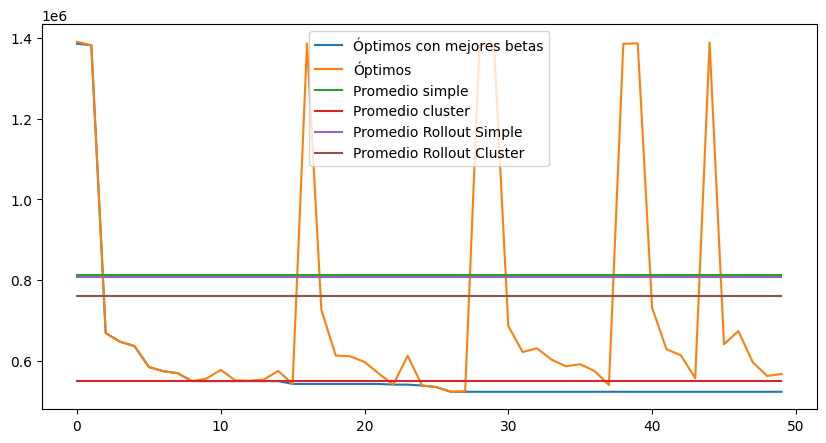

In [20]:
# hacemos un plot de la evolución de los promedios de recompensa
plt.figure(figsize=(10,5))
plt.plot(MC.registro_optimos_mejores_betas, label='Óptimos con mejores betas')
plt.plot(MC.registro_optimos, label='Óptimos')
plt.plot([promedio_simple for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio simple')
plt.plot([promedio_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio cluster')
plt.plot([promedio_costo_rollout_simple for _ in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Simple')
plt.plot([promedio_costo_rollout_cluster for i in range(len(MC.registro_optimos_mejores_betas))], label='Promedio Rollout Cluster')

plt.legend() # Esto muestra las leyendas en el gráfico
plt.show()

In [ ]:
costos = np.array([])
n=100
for _ in range(n):
    trayectoriaSimple, costo_traslado = MC.ejecutar_politica_mejores_betas()
    #for estado_accion in trayectoriaSimple:
        #print(estado_accion['estado'])
        #print(estado_accion['accion'])
    costo =sum(estado_accion['recompensa'] for estado_accion in trayectoriaSimple)
    costos = np.append(costos,costo)
promedio = np.mean(costos)
promedio